<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/Copia_de_bloque03_04_redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bloque 03 - Unidad 04: Redes neuronales

Las redes neuronales son modelos computacionales inspirados en el cerebro humano, diseñados para aprender patrones en grandes volúmenes de datos. Están formadas por neuronas interconectadas organizadas en capas: una capa de entrada, varias capas ocultas y una capa de salida. A través de un proceso de ajuste de pesos llamado retropropagación, la red aprende a mejorar sus predicciones.

## Para fijar ideas

1. Escribí una función para un perceptrón genérico de dos entradas y una salida.
2. Usando esa función, escribí una compuerta OR.
3. Usando esa función, escribí una compuerta AND.
4. Combinando varias de esas funciones, escribí una compuerta XOR.

In [ ]:
#z = w1*x01 + w2*x02 + b
#w1 y w2 son pesos
def perceptronGenerico(x01,x02, w1, w2, b):
    return w1*x01 + w2*x02 + b



In [ ]:
#Compuerta or
def compuerta_or(x01,x02, w1, w2, b = -0.5):
    if perceptronGenerico(x01,x02, w1, w2, b) < 0:
        return 0
    else:
        return 1
print(compuerta_or(0,0,1,1))
print(compuerta_or(1,0,1,1))
print(compuerta_or(0,1,1,1))
print(compuerta_or(1,1,1,1))

0
1
1
1


In [ ]:
def compuerta_and(x01,x02, w1, w2, b = -1):
    if perceptronGenerico(x01,x02, w1, w2,b)<=0:
        return 0
    else:
        return 1
print(compuerta_and(0,0,1,1))
print(compuerta_and(1,0,1,1))
print(compuerta_and(0,1,1,1))
print(compuerta_and(1,1,1,1))

0
0
0
1


In [ ]:
def compuerta_xor(x01, x02):
    # Implement XOR using OR, NAND, and AND gates
    # OR gate
    or_result = compuerta_or(x01, x02, 1, 1, -0.5)
    # NAND gate (AND with inverted output)
    nand_result = 1 - compuerta_and(x01, x02, 1, 1, -1.5) # Note the change in bias for NAND
    # AND gate of OR and NAND results
    xor_result = compuerta_and(or_result, nand_result, 1, 1, -1.5) # Note the change in bias for this final AND

    return xor_result

# Test the XOR gate
print(compuerta_xor(0, 0))
print(compuerta_xor(1, 0))
print(compuerta_xor(0, 1))
print(compuerta_xor(1, 1))

0
1
1
0


Un perceptron generico es la unidad basica de las redes neuronales artificiales, que basa en el modelo de las neuronas biologicas, representa un modelado matematico de flujo de información<br>
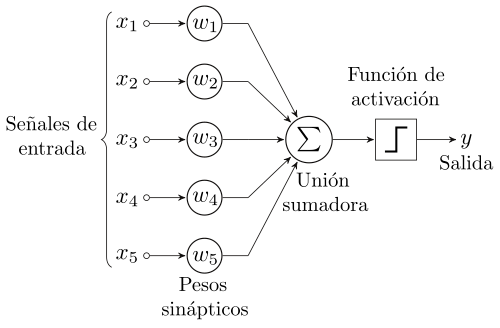

## Identificación de dígitos

0. Lee la documentación de neural networks de sklearn
1. Cargá la base de datos MNIST de dígitos escritos a mano.
2. Si no lo hiciste aún, visualizá los elementos de la base de datos.
3. Un clasificador basado en redes neuronales ¿Cuantos inputs tiene? ¿Cuantos outputs tiene?
4. Armá el clasificador con 2 capas ocultas de 32 neuronas cada una.
5. Entrená la red y evaluá la calidad del resultado con una matriz de confusión.
6. Visualizado la calidad del resultado.

Observa la matriz de confusión: ¿Hay algún dígito específico que se confunda más con otros? ¿Por qué podría estar sucediendo esto? ¿Podrías mejorar el modelo para estos casos?

**Para hacer en casa*: ¿Cómo podés obtener la curva en función del número de epochs?

In [ ]:
from keras.datasets import mnist

# Load the MNIST dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()
print("Train images shape:", train_X.shape)  # (60000, 28, 28)
print("Train labels shape:", train_y.shape)  # (60000,)
print("Test images shape:", test_X.shape)    # (10000, 28, 28)
print("Test labels shape:", test_y.shape)   # (10000,)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


Número de Inputs (Entradas):

    784 inputs (uno por cada píxel de la imagen).
    Cada imagen en MNIST tiene dimensiones de 28×28 píxeles, lo que resulta en:
    28 * 28 = 784 valores de entrada (normalizados entre 0 y 1).
    (Cada píxel es una característica de entrada).

Número de Outputs (Salidas):

    10 outputs (uno por cada dígito posible: 0, 1, 2, ..., 9).
    La red neuronal devuelve una distribución de probabilidades (usando softmax en la última capa), donde cada salida representa la probabilidad de que la imagen pertenezca a esa clase.

In [ ]:
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.datasets import mnist
import numpy as np

# 1. Cargar los datos (ejemplo con MNIST)
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# 2. Reformatear los datos de 3D a 2D (aplanar las imágenes)
train_X = train_X.reshape(train_X.shape[0], -1)  # Convierte (60000, 28, 28) → (60000, 784)
test_X = test_X.reshape(test_X.shape[0], -1)     # Convierte (10000, 28, 28) → (10000, 784)

# 3. Normalizar los valores de píxeles (0-255 → 0-1)
train_X = train_X / 255.0
test_X = test_X / 255.0

# 4. Crear y entrenar el MLPClassifier
clf = MLPClassifier(
    solver='lbfgs',
    alpha=1e-5,
    hidden_layer_sizes=(32, 32),  # Dos capas ocultas con 32 neuronas cada una
    random_state=1,
    max_iter=100  # Aumentar iteraciones para convergencia
)

clf.fit(train_X, train_y)

# 5. Evaluar el modelo
print("Precisión en entrenamiento:", clf.score(train_X, train_y))
print("Precisión en prueba:", clf.score(test_X, test_y))

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Precisión en entrenamiento: 0.9691666666666666
Precisión en prueba: 0.9625


<Figure size 1000x800 with 0 Axes>

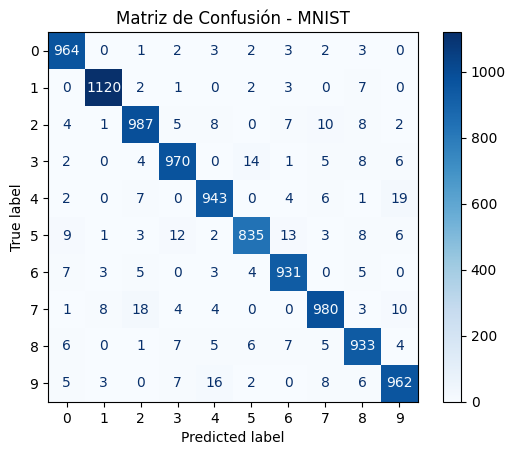

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(test_X)
cm = confusion_matrix(test_y, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - MNIST")
plt.show()



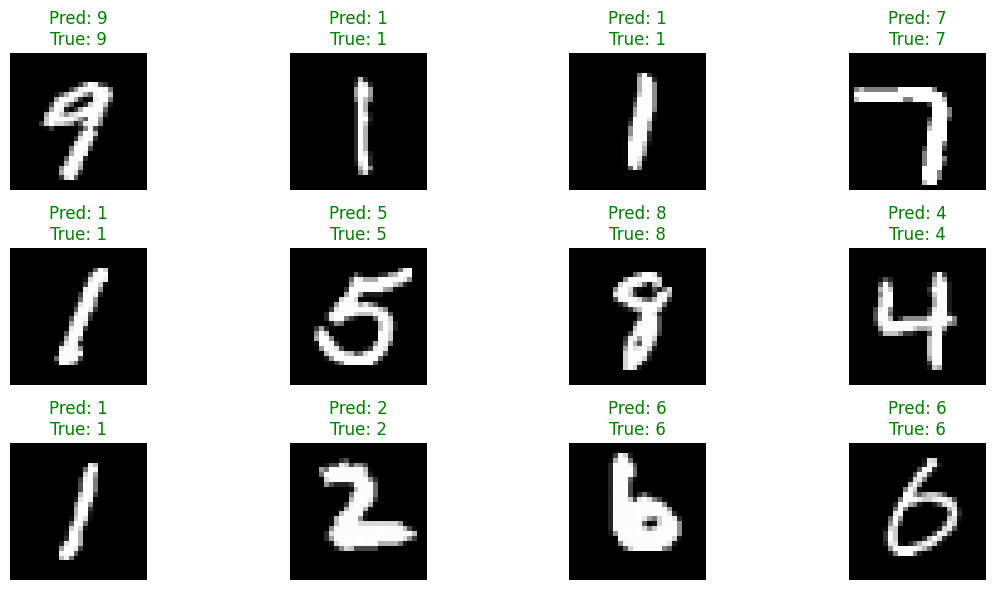

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(12):
    idx = np.random.randint(0, len(test_X))
    plt.subplot(3, 4, i+1)
    plt.imshow(test_X[idx].reshape(28, 28), cmap='gray')
    pred = clf.predict([test_X[idx]])[0]
    true_label = test_y[idx]
    color = 'green' if pred == true_label else 'red'
    plt.title(f"Pred: {pred}\nTrue: {true_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Optimización del modelo

1. Hace hyperparameter optimization para elegir los mejores `hidden_layer_sizes`, `activation`, `learning_rate` y `regularization`
2. Compará el modelo obtenido contra el original en el punto anterior.

## Interactuando con la realidad

1. Escribí dígitos en un papel.
2. Sacale foto, y recortá cada digitos. Llevalo al mismo formato usado en MNDIST
3. ¿Funciona la red que entrenaste con tu escritura?

**Para hacer en casa**: Elegí cualquiera de los datasets de las clases anteriores y armá resolvelo con redes neuronales y compará. Hacelo para un problema de clasificación y uno de regresión.

# Task
Optimize the hyperparameters `hidden_layer_sizes`, `activation`, `learning_rate_init`, and `alpha` of an `MLPClassifier` using hyperparameter optimization. Compare the performance of the optimized model against the original model from the previous step.

## Define the hyperparameter search space

### Subtask:
Define the hyperparameter search space for the MLPClassifier, including `hidden_layer_sizes`, `activation`, `learning_rate_init`, and `alpha`.


**Reasoning**:
Define the hyperparameter grid for the MLPClassifier to be used in hyperparameter optimization.



In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50, 25)],
    'activation': ['tanh', 'relu'],
    'learning_rate_init': [0.0001, 0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}

## Choose a hyperparameter optimization strategy

### Subtask:
Choose a hyperparameter optimization strategy and prepare for the search.


**Reasoning**:
Import GridSearchCV and instantiate the MLPClassifier and GridSearchCV objects to prepare for hyperparameter optimization.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(max_iter=1000, random_state=1)

grid_search = GridSearchCV(mlp, param_grid, cv=3)

## Perform the hyperparameter search

### Subtask:
Perform the hyperparameter search using the defined grid search object on the training data.


**Reasoning**:
Perform the grid search on the training data and print the best parameters and score found.



In [ ]:
grid_search.fit(train_X, train_y)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)